In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras.models import load_model



In [5]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
X_train, X_test = X_train / 255.0, X_test / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.9001 - loss: 0.3252 - val_accuracy: 0.9817 - val_loss: 0.0575
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9853 - loss: 0.0490 - val_accuracy: 0.9866 - val_loss: 0.0355
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9895 - loss: 0.0318 - val_accuracy: 0.9904 - val_loss: 0.0285
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9932 - loss: 0.0221 - val_accuracy: 0.9884 - val_loss: 0.0380
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9905 - val_loss: 0.0296


In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.3f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9867 - loss: 0.0390
Test accuracy: 0.990


In [9]:
import cv2

TypeError: Image data of dtype object cannot be converted to float

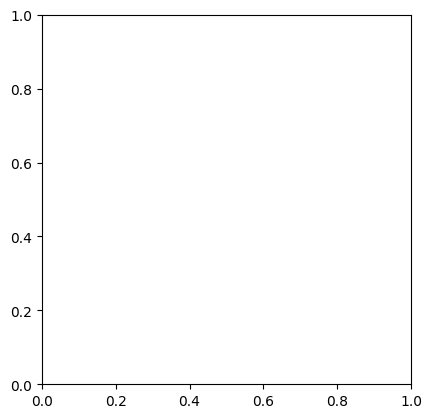

In [10]:
img_path = "img.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()
img = cv2.resize(img, (28, 28))
img = 255 - img

img = img / 255.0
img = img.reshape(1, 28, 28, 1)


In [ ]:
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
print("Predicted Digit:", predicted_class)


In [12]:
# After training your model
model.save("digit_model.h5")   # Save as single file


In [14]:
from google.colab import files
files.download("digit_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>